In [41]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # adds assay_calibration/ to path
sys.path.insert(0, os.path.abspath("../src"))  # adds assay_calibration/src/ for evidence_thresholds

from tavtigian_sims import prior_grid
import importlib
import tavtigian_sims.compare
importlib.reload(tavtigian_sims.compare)
from tavtigian_sims.compare import run_all_methods, plot_three_way_comparison, \
    plot_boundary_posteriors_three_way, plot_additivity_experiment, plot_combined_error_comparison, plot_additivity_dilemma, \
    plot_slope_geometry, plot_combination_paths

In [4]:
priors = prior_grid("paper")
t, pw, pw_add, cont = run_all_methods(priors, n_jobs=10)

In [24]:
cont

,prior,acmg_mapping_method,lr_B,log10_lr_B,post_B,lr_LB,log10_lr_LB,post_LB,lr_LP,log10_lr_LP,post_LP,lr_P,log10_lr_P,post_P
0,0.010000,continuous,1.000000,0.000000,0.01,11.000000,1.041393,0.1,891.000000,2.949878,0.9,9801.000000,3.991270,0.99
1,0.011472,continuous,0.870424,-0.060269,0.01,9.574668,0.981124,0.1,775.548105,2.889609,0.9,8531.029155,3.931001,0.99
2,0.012943,continuous,0.770313,-0.113333,0.01,8.473442,0.928060,0.1,686.348837,2.836545,0.9,7549.837209,3.877938,0.99
3,0.014415,continuous,0.690642,-0.160747,0.01,7.597061,0.880646,0.1,615.361949,2.789131,0.9,6768.981439,3.830523,0.99
4,0.015886,continuous,0.625731,-0.203612,0.01,6.883041,0.837780,0.1,557.526316,2.746265,0.9,6132.789474,3.787658,0.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0.444114,continuous,0.012643,-1.898143,0.01,0.139075,-0.856751,0.1,11.265080,1.051734,0.9,123.915882,2.093127,0.99
296,0.445585,continuous,0.012568,-1.900731,0.01,0.138249,-0.859339,0.1,11.198154,1.049146,0.9,123.179689,2.090539,0.99
297,0.447057,continuous,0.012493,-1.903317,0.01,0.137428,-0.861925,0.1,11.131668,1.046560,0.9,122.448343,2.087953,0.99
298,0.448528,continuous,0.012419,-1.905902,0.01,0.136613,-0.864509,0.1,11.065618,1.043976,0.9,121.721796,2.085368,0.99


(<Figure size 1100x600 with 1 Axes>,
 <Axes: title={'center': 'LR+ thresholds vs prior  [Tavtigian (C*), Piecewise α (ACMG)]  (pathogenic above 0, benign below 0)'}, xlabel='Prior probability of pathogenicity', ylabel='log₁₀(LR+)'>)

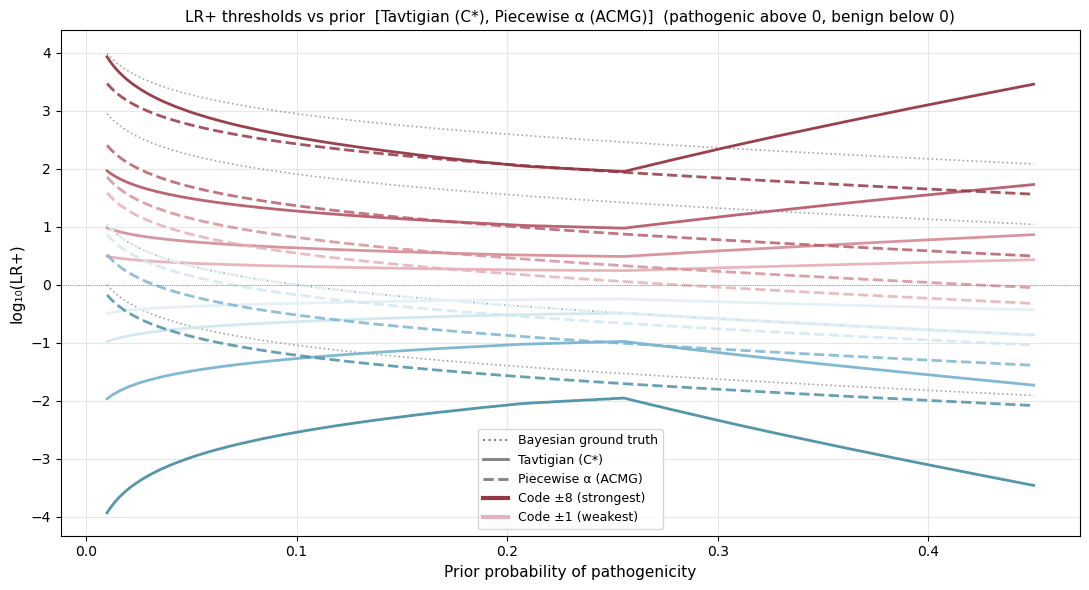

In [26]:
plot_three_way_comparison(t, pw, cont_df=cont, log_scale=False, codes="key")

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': 'P / LP boundary posteriors'}, xlabel='Prior', ylabel='Posterior P(pathogenic)'>,
        <Axes: title={'center': 'LB / B boundary posteriors'}, xlabel='Prior', ylabel='Posterior P(pathogenic)'>],
       dtype=object))

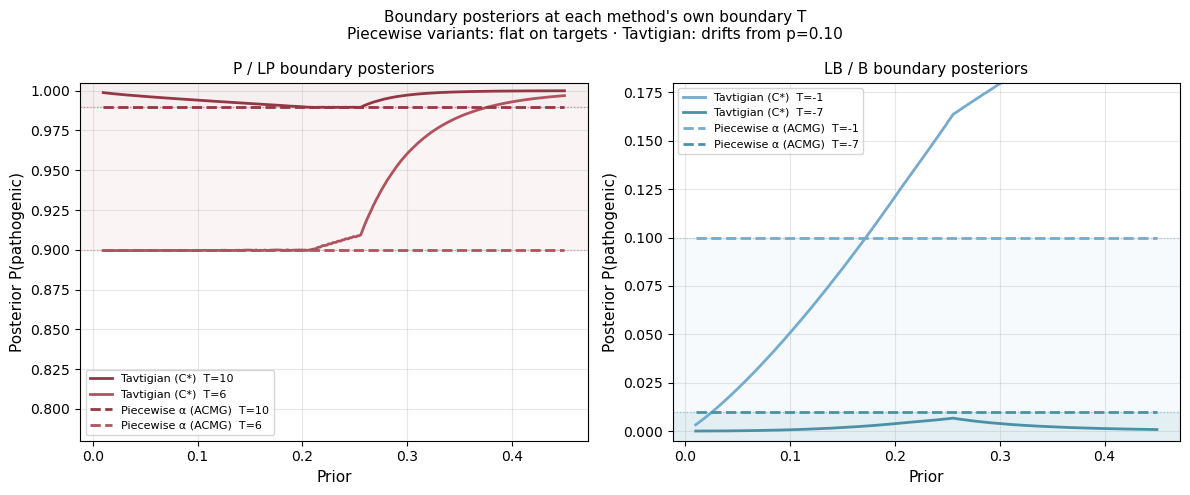

In [18]:
plot_boundary_posteriors_three_way(t, pw, log_scale=False)  # 4 methods

/home/rcstewart/assay_calibration/tavtigian_sims/compare.py:755: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ll4_pa = float(piecewise_additive_log_lr(4, float(p)))


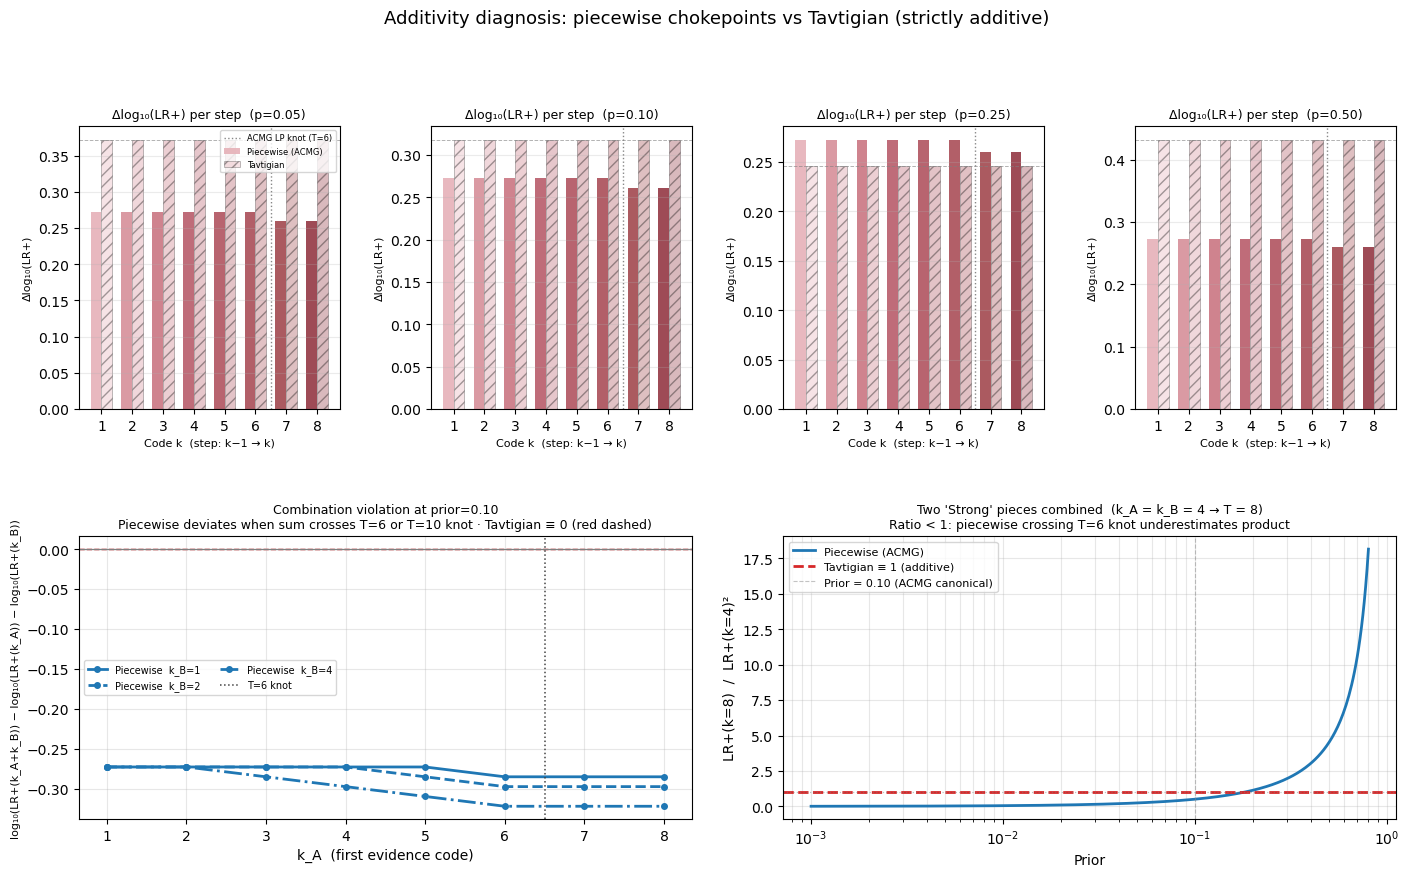

In [19]:
fig, axes = plot_additivity_experiment(
    priors=(0.05, 0.10, 0.25, 0.50),   # which priors to show in the slope panels (row 0)
    tav_df=t,                            # reuses precomputed C* — avoids re-running grid search
    pw_add_df=pw_add
)

(<Figure size 1400x1200 with 4 Axes>,
 array([[<Axes: title={'center': 'Single-assay boundary error\nPiecewise: always 0 · Tavtigian: drifts from calibrated p=0.10'}, xlabel='Prior', ylabel='|posterior − target|'>,
         <Axes: title={'center': 'Two-assay combination error vs prior\nPiecewise self-consistency (solid) · Tavtigian vs PW reference (faint)'}, xlabel='Prior', ylabel='Combined posterior − true posterior'>],
        [<Axes: title={'center': 'Net winner per combination (+ = piecewise better)\nBoth measured vs same piecewise per-code LR+ reference'}, xlabel='Prior', ylabel='|err_Tavtigian| − |err_Piecewise|'>,
         <Axes: title={'center': 'Absolute combination error at two priors\nTavtigian (solid) vs Piecewise self-consistency (hatched)\nBoth vs piecewise per-code LR+ product as reference'}, xlabel='Evidence combination (k_A, k_B)', ylabel='|combined posterior − reference posterior|'>]],
       dtype=object))

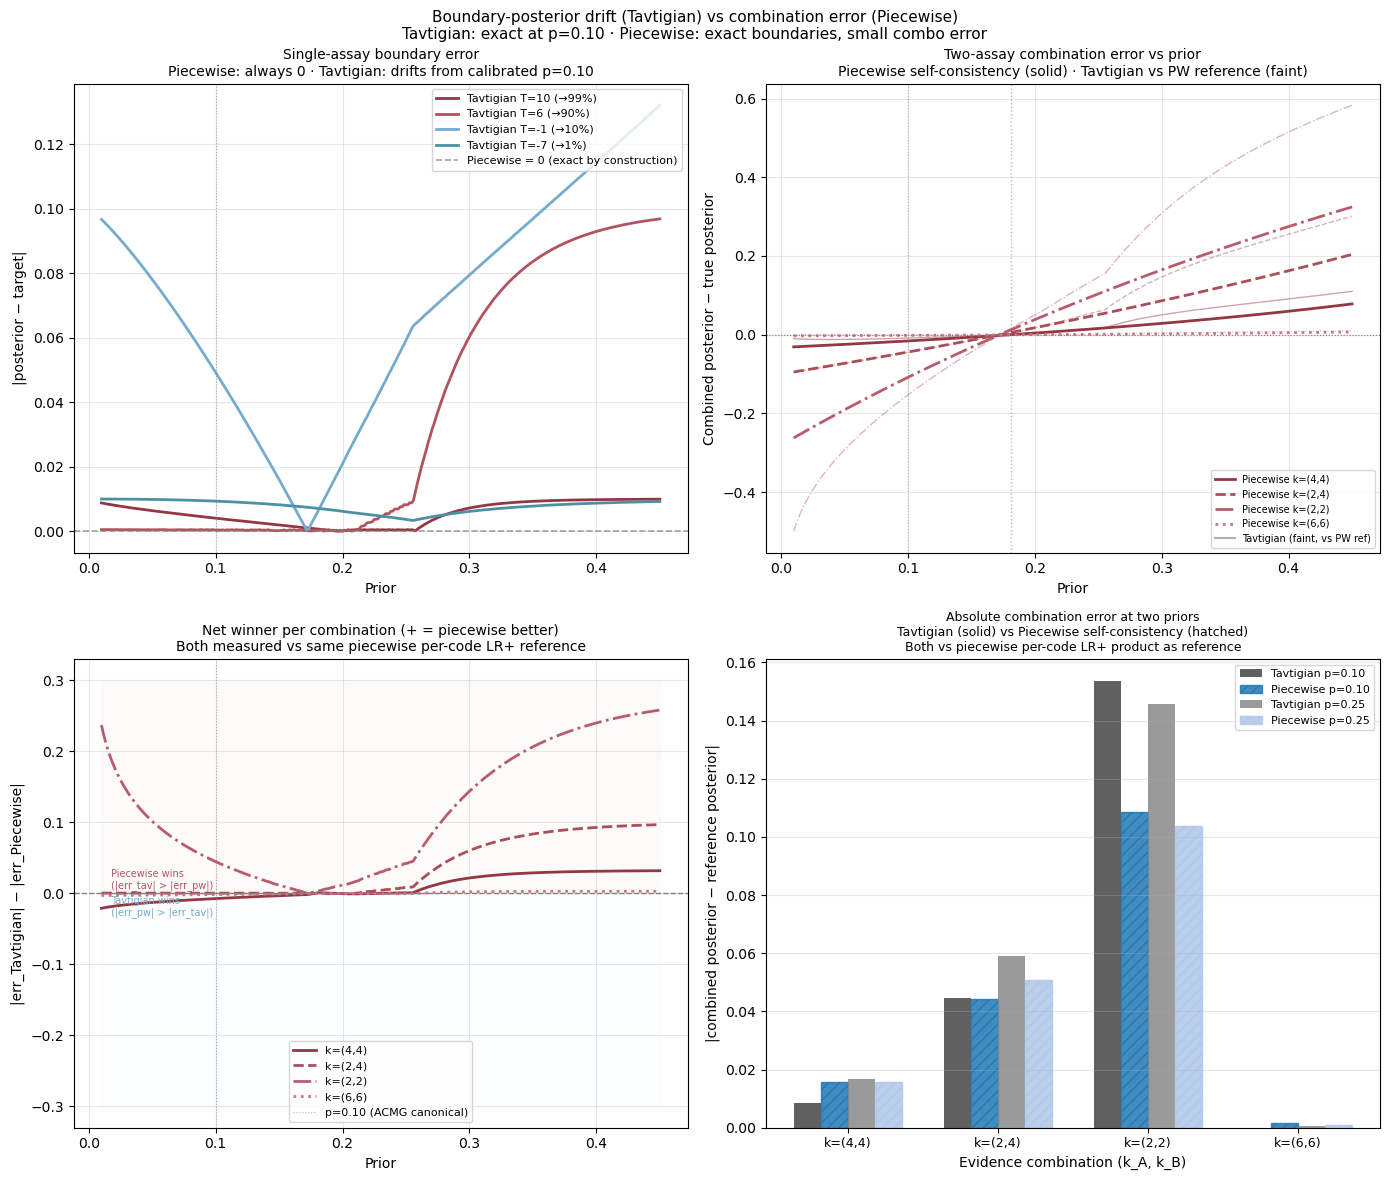

In [20]:
plot_combined_error_comparison(priors, tav_df=t, pw_add_df=pw_add, log_scale=False)

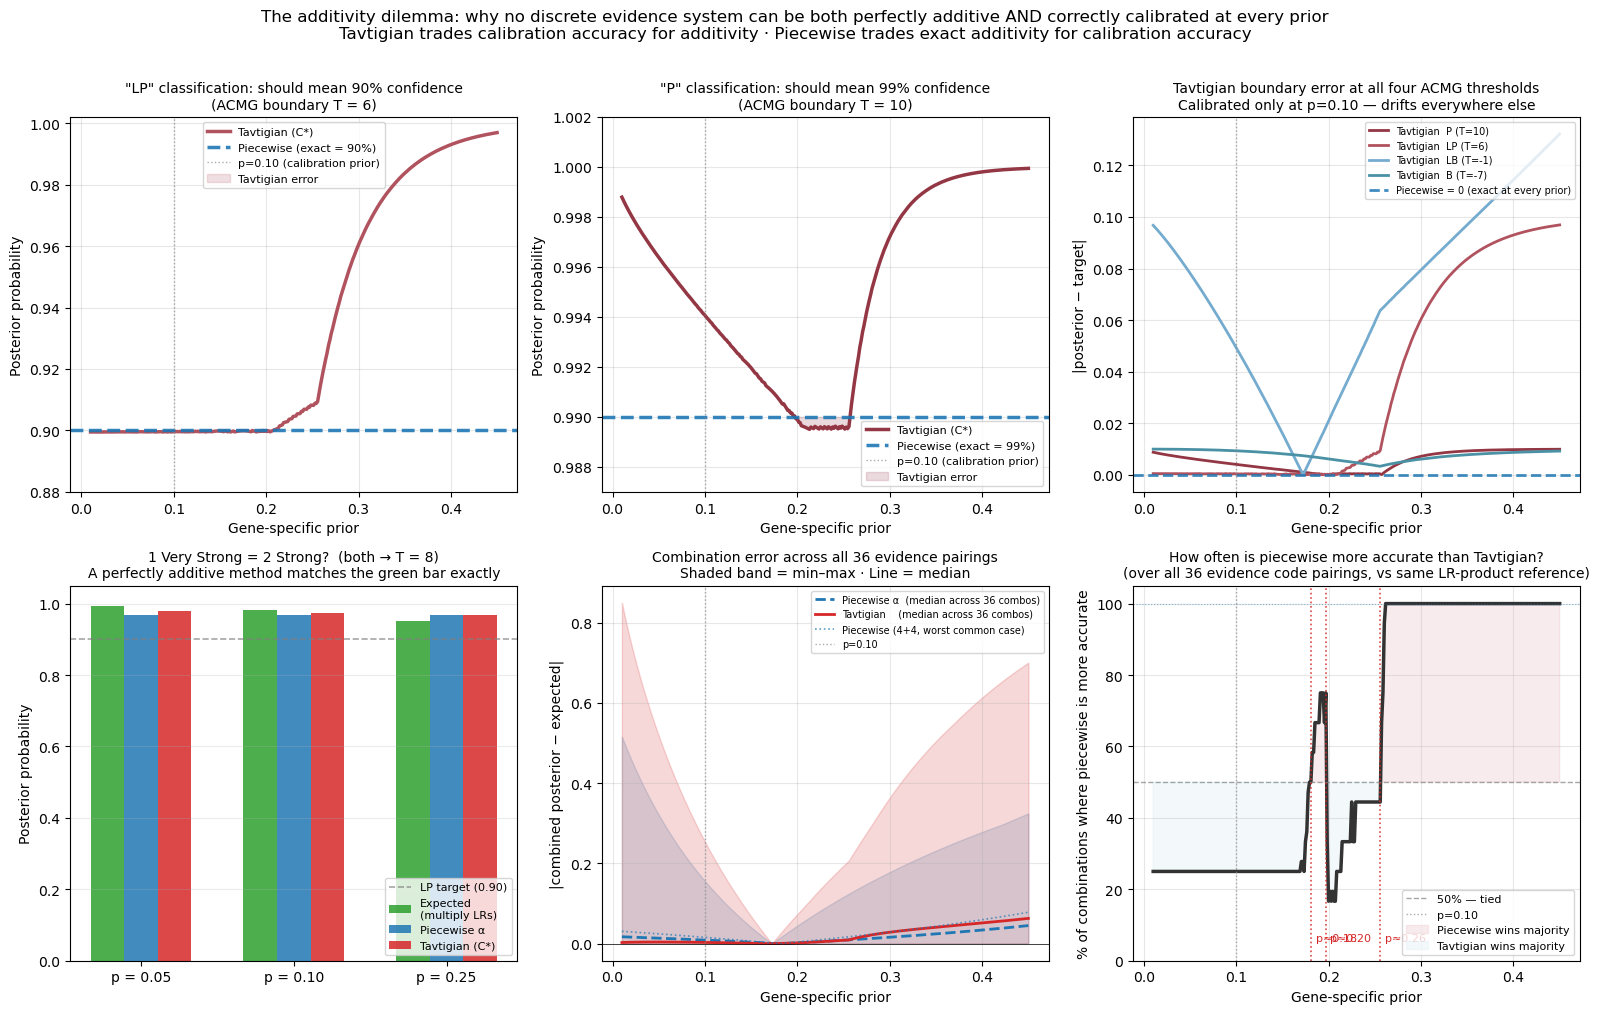

In [33]:
fig, axes = plot_additivity_dilemma(priors, tav_df=t)

In [36]:
from tavtigian_sims import prior_grid
from tavtigian_sims.compare import (
    run_all_methods,
    plot_additivity_dilemma,
    plot_slope_geometry,
)

priors = prior_grid("paper")
t, pw, pw_add, cont = run_all_methods(priors, n_jobs=10)

fig, _ = plot_additivity_dilemma(priors, tav_df=t)
fig.savefig('figures/additivity_dilemma.pdf', bbox_inches='tight')

fig, _ = plot_slope_geometry(tav_df=t)
fig.savefig('figures/slope_geometry.pdf', bbox_inches='tight')



KeyboardInterrupt


KeyboardInterrupt



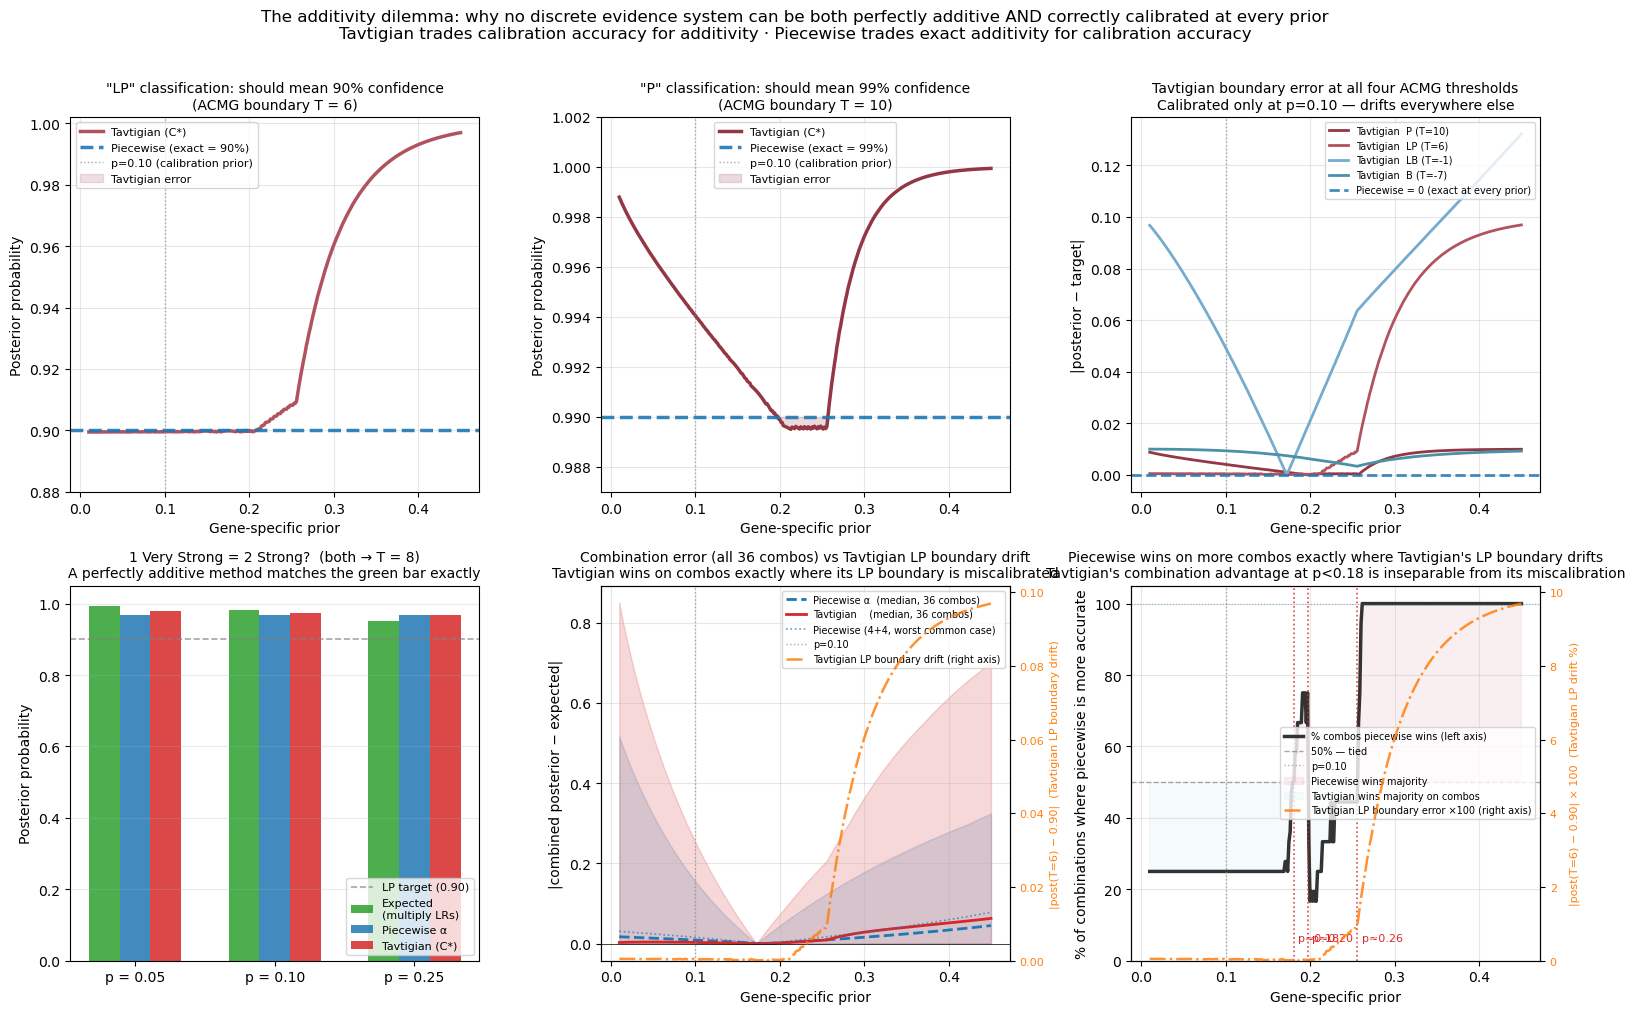

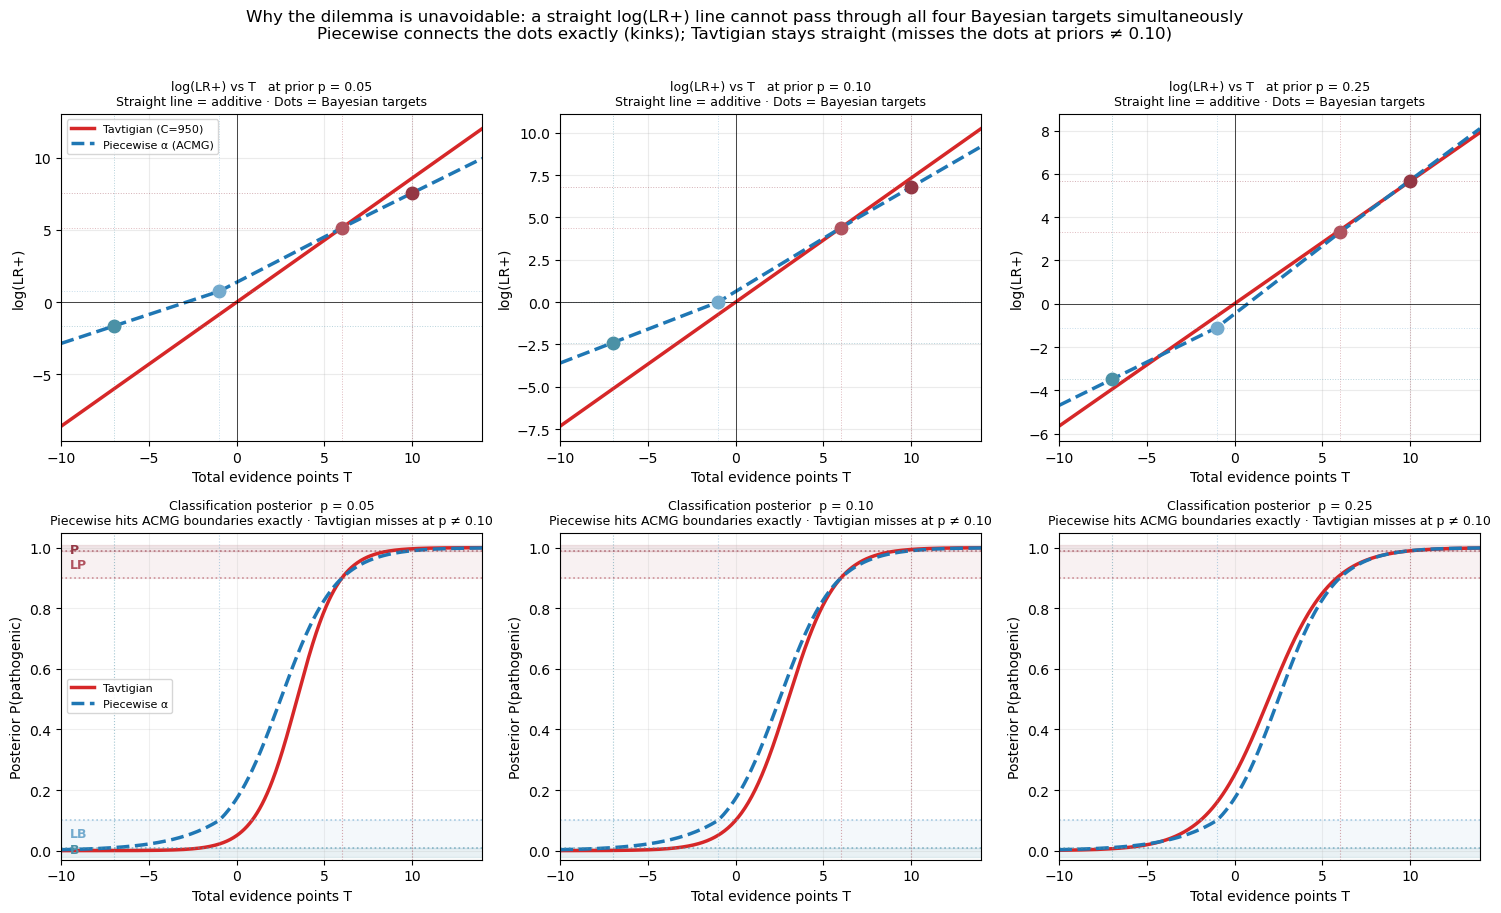

In [40]:
fig, _ = plot_additivity_dilemma(priors, tav_df=t)
fig.savefig('figures/additivity_dilemma.pdf', bbox_inches='tight')

fig, _ = plot_slope_geometry(tav_df=t)
fig.savefig('figures/slope_geometry.pdf', bbox_inches='tight')

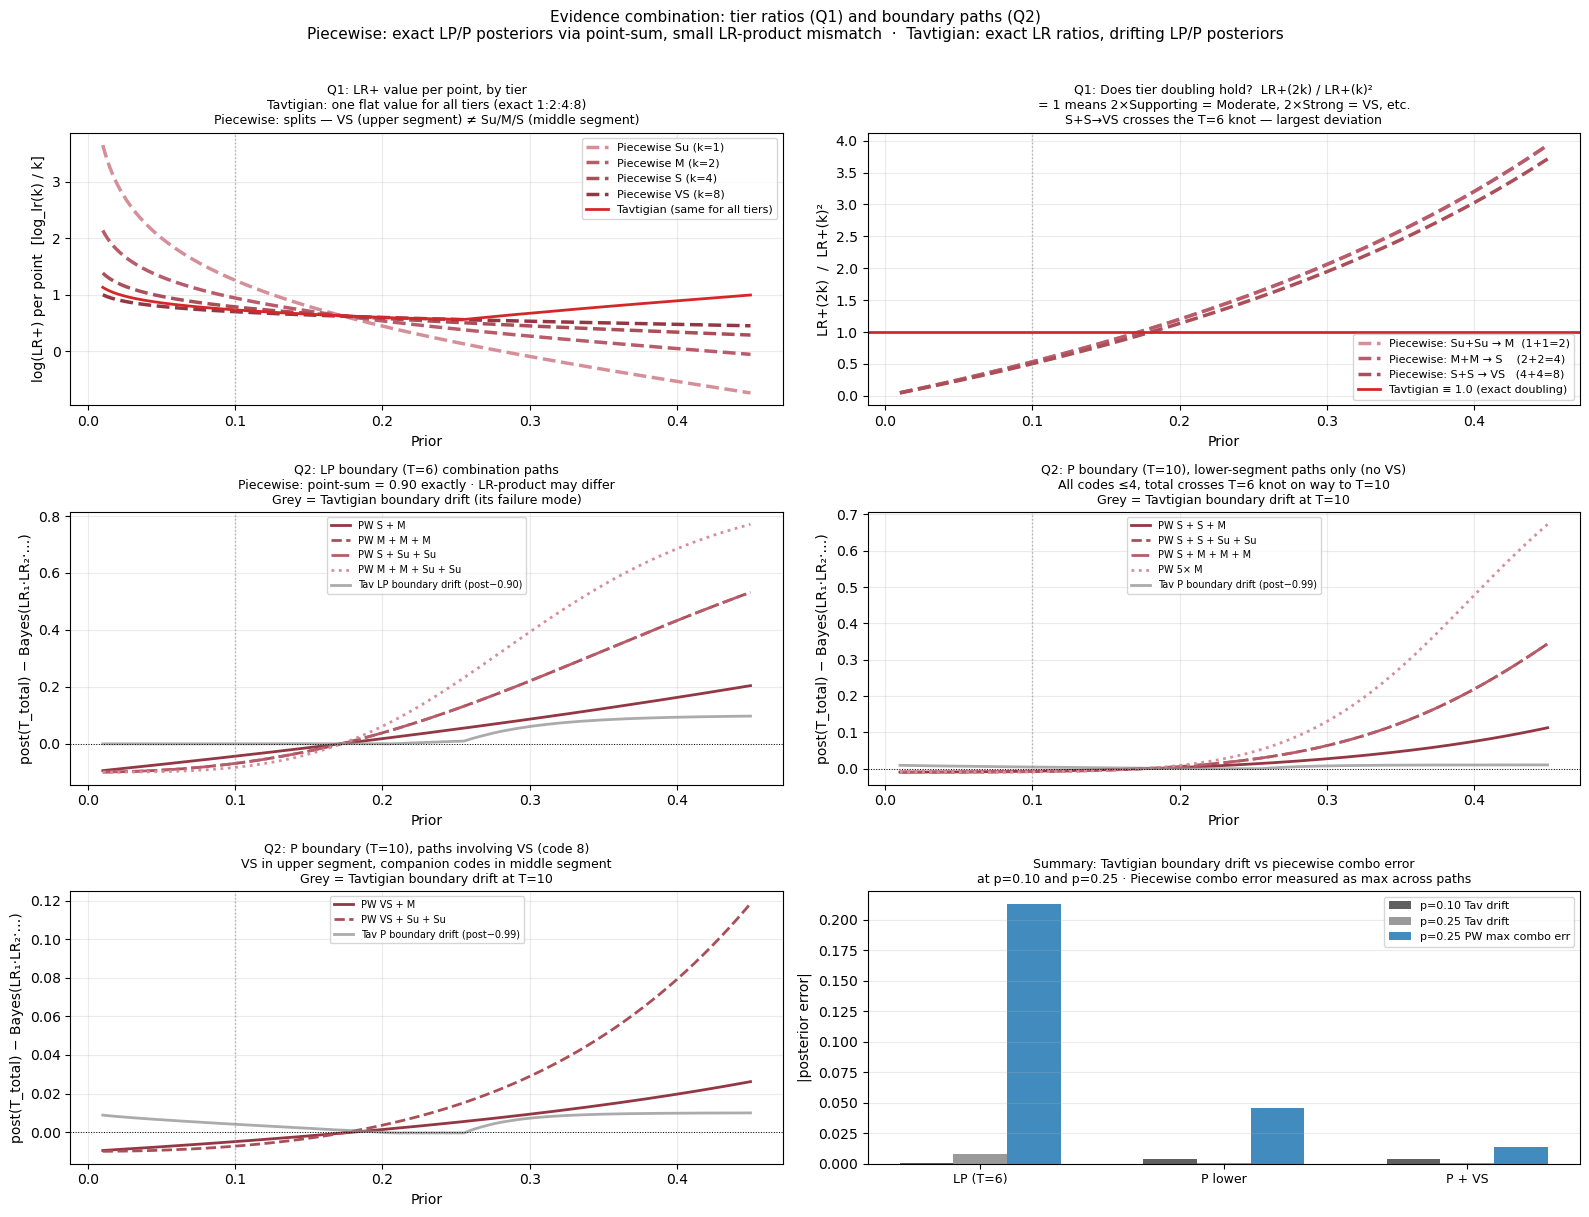

In [42]:
fig, axes = plot_combination_paths(priors, tav_df=t)